*This is a template project. It uses synthetic data so it runs anywhere; swap in your own dataset and write-up.*

## The question

Is there a measurable warming trend once seasonality is removed?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Synthetic daily temperatures: seasonal cycle + slow trend + noise
rng = np.random.default_rng(42)
dates = pd.date_range('2016-01-01', '2025-12-31', freq='D')
t = np.arange(len(dates))
temp = 55 + 22 * np.sin(2 * np.pi * (t - 105) / 365.25) + 0.0006 * t + rng.normal(0, 5, len(dates))
df = pd.DataFrame({'date': dates, 'temp_f': temp}).set_index('date')
df.describe().round(1)

,temp_f
count,3653.0
mean,56.0
std,16.3
min,21.1
25%,41.1
50%,56.0
75%,70.6
max,92.4


## Seasonality

Monthly averages show the expected annual cycle.

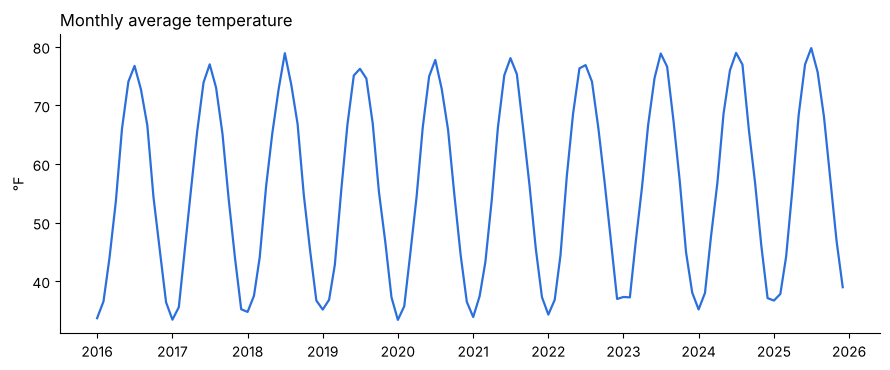

In [2]:
monthly = df['temp_f'].resample('MS').mean()
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(monthly.index, monthly, color='#2a6fdb', lw=1.6)
ax.set_title('Monthly average temperature', loc='left')
ax.set_ylabel('°F')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('thumbnail.png', dpi=120)
plt.show()

## Trend

Averaging by year removes the seasonal cycle, and a linear fit estimates the trend.

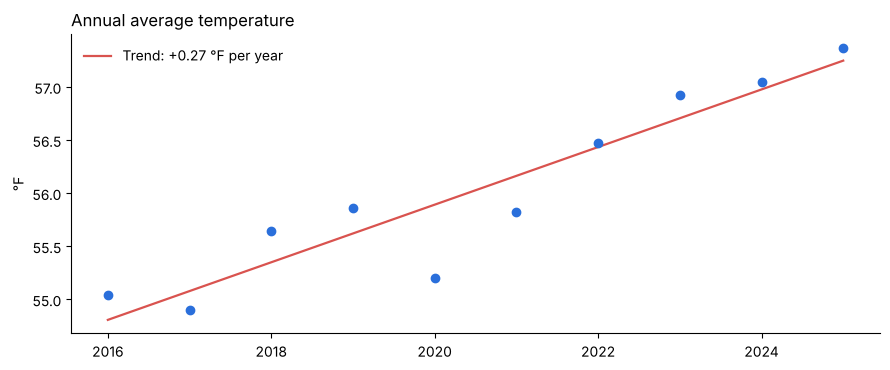

Estimated trend: +0.27 °F per year (+2.7 °F per decade)


In [3]:
yearly = df['temp_f'].resample('YS').mean()
years = yearly.index.year
slope, intercept = np.polyfit(years, yearly.values, 1)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.scatter(years, yearly, color='#2a6fdb', zorder=3)
ax.plot(years, slope * years + intercept, color='#d9534f', lw=1.6, label=f'Trend: {slope:+.2f} °F per year')
ax.set_title('Annual average temperature', loc='left')
ax.set_ylabel('°F')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
print(f'Estimated trend: {slope:+.2f} °F per year ({slope * 10:+.1f} °F per decade)')

## Takeaways

1. State your main finding with a number.
2. Note a limitation of the data or method.
3. Say what you would do next.